# Big CSV Explorer
Joined dataset: FTS funding requirements + HNO people-in-need + IPC food-security phases, keyed on `countryCode × cluster × year`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path

DATA = Path('../data')

df = pd.read_csv(DATA / 'big_analysis.csv')
print(f'{df.shape[0]} rows × {df.shape[1]} cols')
df.head()

363 rows × 26 cols


,countryCode,id,name,code,typeId,typeName,startDate_plan_total,endDate_plan_total,year,requirements_plan_total,...,requirements_cluster_specific,funding_cluster_specific,percentFunded_cluster_specific,People_In_Need,ipc_phase_1_people,ipc_phase_2_people,ipc_phase_3_people,ipc_phase_4_people,ipc_phase_5_people,ipc_phase_3plus_people
0,AFG,1185.0,Afghanistan Humanitarian Needs and Response Pl...,HAFG24,2070.0,Humanitarian needs and response plan,2024-01-01,2024-12-31,2024,3.059588e+09,...,NaN,0.0,NaN,0.0,28306268.0,36414628.0,21086794.0,4731819.0,0.0,25818613.0
1,AFG,1185.0,Afghanistan Humanitarian Needs and Response Pl...,HAFG24,2070.0,Humanitarian needs and response plan,2024-01-01,2024-12-31,2024,3.059588e+09,...,3.595177e+07,16550286.0,46.0,0.0,28306268.0,36414628.0,21086794.0,4731819.0,0.0,25818613.0
2,AFG,1185.0,Afghanistan Humanitarian Needs and Response Pl...,HAFG24,2070.0,Humanitarian needs and response plan,2024-01-01,2024-12-31,2024,3.059588e+09,...,1.400220e+08,78206912.0,56.0,8030371.0,28306268.0,36414628.0,21086794.0,4731819.0,0.0,25818613.0
3,AFG,1185.0,Afghanistan Humanitarian Needs and Response Pl...,HAFG24,2070.0,Humanitarian needs and response plan,2024-01-01,2024-12-31,2024,3.059588e+09,...,2.271048e+08,73572110.0,32.0,6609590.0,28306268.0,36414628.0,21086794.0,4731819.0,0.0,25818613.0
4,AFG,1185.0,Afghanistan Humanitarian Needs and Response Pl...,HAFG24,2070.0,Humanitarian needs and response plan,2024-01-01,2024-12-31,2024,3.059588e+09,...,1.431356e+09,697096059.0,49.0,15823677.0,28306268.0,36414628.0,21086794.0,4731819.0,0.0,25818613.0


## Schema & nulls

In [2]:
summary = pd.DataFrame({
    'dtype': df.dtypes,
    'nulls': df.isna().sum(),
    'null_%': (df.isna().mean() * 100).round(1),
    'unique': df.nunique(),
    'sample': df.iloc[0],
})
summary

,dtype,nulls,null_%,unique,sample
countryCode,str,0,0.0,24,AFG
id,float64,0,0.0,26,1185.0
name,str,0,0.0,26,Afghanistan Humanitarian Needs and Response Pl...
code,str,0,0.0,26,HAFG24
typeId,float64,0,0.0,4,2070.0
typeName,str,0,0.0,4,Humanitarian needs and response plan
startDate_plan_total,str,0,0.0,3,2024-01-01
endDate_plan_total,str,0,0.0,1,2024-12-31
year,int64,0,0.0,1,2024
requirements_plan_total,float64,0,0.0,26,3059587797.0


## Coverage: countries, clusters, years

In [3]:
print('Years:   ', sorted(df['year'].unique()))
print('Clusters:', sorted(df['cluster'].unique()))
print('Countries:', sorted(df['countryCode'].unique()))

Years:    [np.int64(2024)]
Clusters: ['Agriculture', 'Camp Coordination / Management', 'Coordination and support services', 'Early Recovery', 'Education', 'Emergency Shelter and NFI', 'Food Security', 'Health', 'Logistics', 'Multi-sector', 'Nutrition', 'Protection', 'Protection - Child Protection', 'Protection - Gender-Based Violence', 'Protection - Housing, Land and Property', 'Protection - Mine Action', 'Water Sanitation Hygiene']
Countries: ['AFG', 'BFA', 'CAF', 'CMR', 'COD', 'COL', 'ETH', 'GTM', 'HND', 'HTI', 'MLI', 'MMR', 'MOZ', 'NER', 'NGA', 'SDN', 'SLV', 'SOM', 'SSD', 'SYR', 'TCD', 'UKR', 'VEN', 'YEM']


## Filter: pick a country / cluster / year
Edit the variables below to slice the data interactively.

In [4]:
COUNTRY  = None   # e.g. 'AFG' — None shows all
CLUSTER  = None   # e.g. 'Food Security' — None shows all
YEAR     = None   # e.g. 2024 — None shows all

mask = pd.Series(True, index=df.index)
if COUNTRY:  mask &= df['countryCode'] == COUNTRY
if CLUSTER:  mask &= df['cluster'] == CLUSTER
if YEAR:     mask &= df['year'] == YEAR

view = df[mask].copy()
print(f'{len(view)} rows after filter')
view[[
    'countryCode', 'year', 'cluster',
    'requirements_cluster_specific', 'funding_cluster_specific', 'percentFunded_cluster_specific',
    'People_In_Need',
    'ipc_phase_1_people', 'ipc_phase_2_people', 'ipc_phase_3_people',
    'ipc_phase_4_people', 'ipc_phase_5_people', 'ipc_phase_3plus_people',
]].sort_values(['countryCode', 'cluster'])

363 rows after filter


,countryCode,year,cluster,requirements_cluster_specific,funding_cluster_specific,percentFunded_cluster_specific,People_In_Need,ipc_phase_1_people,ipc_phase_2_people,ipc_phase_3_people,ipc_phase_4_people,ipc_phase_5_people,ipc_phase_3plus_people
0,AFG,2024,Agriculture,NaN,0.0,NaN,0.0,28306268.0,36414628.0,21086794.0,4731819.0,0.0,25818613.0
1,AFG,2024,Coordination and support services,3.595177e+07,16550286.0,46.0,0.0,28306268.0,36414628.0,21086794.0,4731819.0,0.0,25818613.0
2,AFG,2024,Education,1.400220e+08,78206912.0,56.0,8030371.0,28306268.0,36414628.0,21086794.0,4731819.0,0.0,25818613.0
3,AFG,2024,Emergency Shelter and NFI,2.271048e+08,73572110.0,32.0,6609590.0,28306268.0,36414628.0,21086794.0,4731819.0,0.0,25818613.0
4,AFG,2024,Food Security,1.431356e+09,697096059.0,49.0,15823677.0,28306268.0,36414628.0,21086794.0,4731819.0,0.0,25818613.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,YEM,2024,Protection - Child Protection,3.925314e+07,40914696.0,104.0,7380286.0,2568360.0,2940138.0,3411353.0,1236580.0,0.0,4647933.0
359,YEM,2024,Protection - Gender-Based Violence,5.600000e+07,33148998.0,59.0,6362887.0,2568360.0,2940138.0,3411353.0,1236580.0,0.0,4647933.0
360,YEM,2024,"Protection - Housing, Land and Property",NaN,678413.0,NaN,0.0,2568360.0,2940138.0,3411353.0,1236580.0,0.0,4647933.0
361,YEM,2024,Protection - Mine Action,1.088780e+07,7207413.0,66.0,6977120.0,2568360.0,2940138.0,3411353.0,1236580.0,0.0,4647933.0


## Funding gap by cluster

In [5]:
gap_by_cluster = (
    df.groupby('cluster')[['requirements_cluster_specific', 'funding_cluster_specific']]
    .sum()
    .assign(gap=lambda x: x['requirements_cluster_specific'] - x['funding_cluster_specific'])
    .assign(pct_funded=lambda x: (x['funding_cluster_specific'] / x['requirements_cluster_specific'] * 100).round(1))
    .sort_values('gap', ascending=False)
    .reset_index()
)

fig = px.bar(
    gap_by_cluster,
    x='cluster', y='gap',
    color='pct_funded',
    color_continuous_scale='RdYlGn',
    labels={'gap': 'Funding gap (USD)', 'pct_funded': '% funded'},
    title='Funding gap by cluster (all countries, all years)',
    height=500,
)
fig.update_xaxes(tickangle=45)
fig.show()
gap_by_cluster

,cluster,requirements_cluster_specific,funding_cluster_specific,gap,pct_funded
0,Food Security,1.222731e+10,5.742802e+09,6.484505e+09,47.0
1,Water Sanitation Hygiene,2.832074e+09,1.017856e+09,1.814219e+09,35.9
2,Emergency Shelter and NFI,2.715851e+09,9.219777e+08,1.793874e+09,33.9
3,Health,2.948260e+09,1.348152e+09,1.600108e+09,45.7
4,Nutrition,2.612452e+09,1.463253e+09,1.149199e+09,56.0
5,Education,1.654369e+09,5.558578e+08,1.098511e+09,33.6
6,Multi-sector,1.097243e+09,4.652520e+08,6.319906e+08,42.4
7,Protection - Child Protection,9.784466e+08,3.751551e+08,6.032915e+08,38.3
8,Protection - Gender-Based Violence,8.582469e+08,2.745645e+08,5.836824e+08,32.0
9,Agriculture,3.296887e+08,5.768232e+07,2.720064e+08,17.5


## People in need by cluster

In [6]:
pin_by_cluster = (
    df.groupby('cluster')['People_In_Need']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

fig = px.bar(
    pin_by_cluster, x='cluster', y='People_In_Need',
    title='Total people in need by cluster',
    labels={'People_In_Need': 'People in need'},
    height=450,
)
fig.update_xaxes(tickangle=45)
fig.show()

## IPC food-security phases — country breakdown
Each bar shows how many people fall in each IPC phase (aggregated to country level, current period).

In [7]:
ipc_cols = ['ipc_phase_1_people', 'ipc_phase_2_people', 'ipc_phase_3_people',
            'ipc_phase_4_people', 'ipc_phase_5_people']
phase_labels = {'ipc_phase_1_people': 'Phase 1 – Minimal',
                'ipc_phase_2_people': 'Phase 2 – Stressed',
                'ipc_phase_3_people': 'Phase 3 – Crisis',
                'ipc_phase_4_people': 'Phase 4 – Emergency',
                'ipc_phase_5_people': 'Phase 5 – Famine'}

ipc_by_country = (
    df.drop_duplicates(subset=['countryCode', 'year'])
    .groupby('countryCode')[ipc_cols]
    .sum()
    .rename(columns=phase_labels)
    .reset_index()
)
ipc_by_country['total_ipc'] = ipc_by_country[list(phase_labels.values())].sum(axis=1)
ipc_by_country = ipc_by_country.sort_values('total_ipc', ascending=False).head(25)

fig = px.bar(
    ipc_by_country.melt(id_vars='countryCode', value_vars=list(phase_labels.values()),
                        var_name='IPC Phase', value_name='People'),
    x='countryCode', y='People', color='IPC Phase',
    color_discrete_sequence=px.colors.sequential.YlOrRd,
    title='IPC food-security phases – top 25 countries by total affected',
    height=500,
)
fig.update_xaxes(tickangle=45)
fig.show()

## Top countries by funding gap

In [8]:
gap_by_country = (
    df.groupby('countryCode')[['requirements_cluster_specific', 'funding_cluster_specific']]
    .sum()
    .assign(gap=lambda x: x['requirements_cluster_specific'] - x['funding_cluster_specific'])
    .assign(pct_funded=lambda x: (x['funding_cluster_specific'] / x['requirements_cluster_specific'] * 100).round(1))
    .sort_values('gap', ascending=False)
    .head(20)
    .reset_index()
)

fig = px.bar(
    gap_by_country, x='countryCode', y='gap',
    color='pct_funded',
    color_continuous_scale='RdYlGn',
    labels={'gap': 'Funding gap (USD)', 'pct_funded': '% funded'},
    title='Top 20 countries by funding gap',
    height=450,
)
fig.show()

## IPC crisis severity vs funding gap (scatter)
Do more food-insecure countries get less funding relative to their requirements?

In [9]:
scatter_df = (
    df.drop_duplicates(subset=['countryCode', 'year'])
    .groupby('countryCode')
    .agg(
        ipc_phase_3plus=('ipc_phase_3plus_people', 'sum'),
        requirements=('requirements_cluster_specific', 'sum'),
        funding=('funding_cluster_specific', 'sum'),
        people_in_need=('People_In_Need', 'sum'),
    )
    .assign(pct_funded=lambda x: (x['funding'] / x['requirements'] * 100).round(1))
    .dropna()
    .reset_index()
)

fig = px.scatter(
    scatter_df,
    x='ipc_phase_3plus',
    y='pct_funded',
    size='people_in_need',
    hover_name='countryCode',
    color='pct_funded',
    color_continuous_scale='RdYlGn',
    labels={
        'ipc_phase_3plus': 'People in IPC Phase 3+ (food insecure)',
        'pct_funded': '% of requirements funded',
    },
    title='Food insecurity vs funding coverage — bubble size = total people in need',
    height=550,
)
fig.show()

## Correlation heatmap

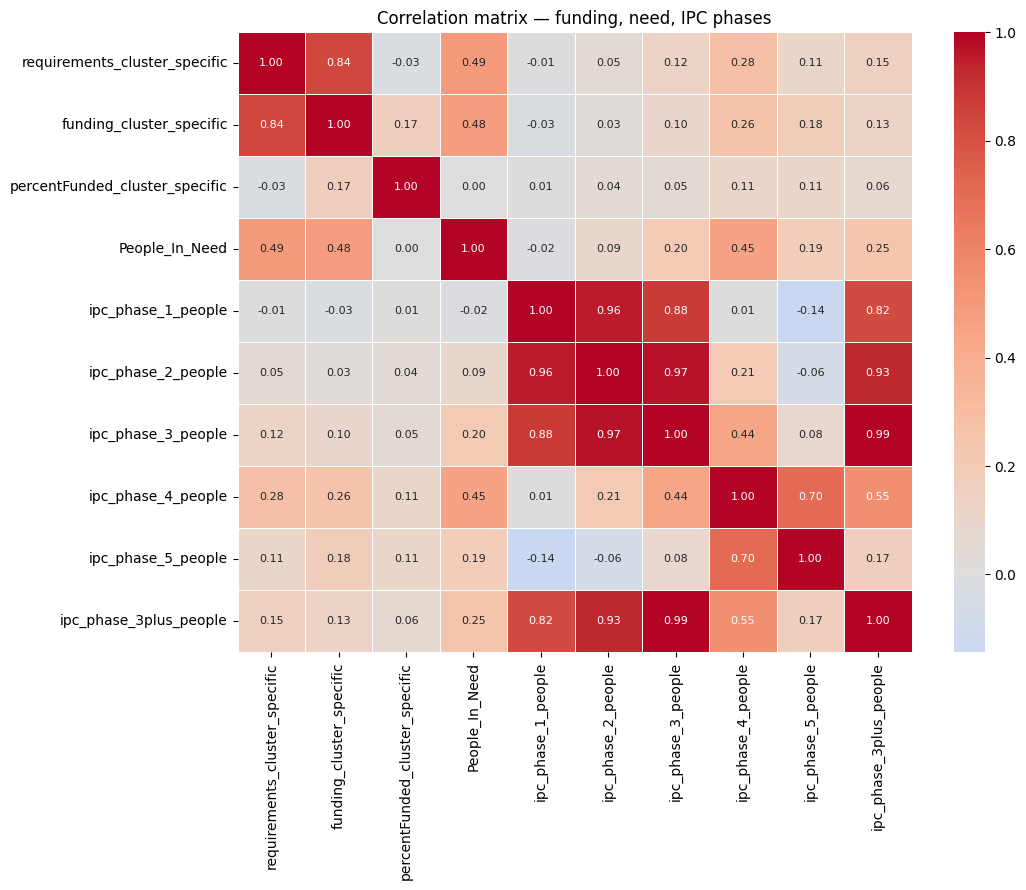

In [10]:
num_cols = [
    'requirements_cluster_specific', 'funding_cluster_specific', 'percentFunded_cluster_specific',
    'People_In_Need',
    'ipc_phase_1_people', 'ipc_phase_2_people', 'ipc_phase_3_people',
    'ipc_phase_4_people', 'ipc_phase_5_people', 'ipc_phase_3plus_people',
]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Correlation matrix — funding, need, IPC phases')
plt.tight_layout()
plt.show()

## Raw filtered table — full columns

In [11]:
# Re-run the filter from the top of the notebook here for convenience
df[mask].sort_values(['countryCode', 'cluster', 'year'])

,countryCode,id,name,code,typeId,typeName,startDate_plan_total,endDate_plan_total,year,requirements_plan_total,...,requirements_cluster_specific,funding_cluster_specific,percentFunded_cluster_specific,People_In_Need,ipc_phase_1_people,ipc_phase_2_people,ipc_phase_3_people,ipc_phase_4_people,ipc_phase_5_people,ipc_phase_3plus_people
0,AFG,1185.0,Afghanistan Humanitarian Needs and Response Pl...,HAFG24,2070.0,Humanitarian needs and response plan,2024-01-01,2024-12-31,2024,3.059588e+09,...,NaN,0.0,NaN,0.0,28306268.0,36414628.0,21086794.0,4731819.0,0.0,25818613.0
1,AFG,1185.0,Afghanistan Humanitarian Needs and Response Pl...,HAFG24,2070.0,Humanitarian needs and response plan,2024-01-01,2024-12-31,2024,3.059588e+09,...,3.595177e+07,16550286.0,46.0,0.0,28306268.0,36414628.0,21086794.0,4731819.0,0.0,25818613.0
2,AFG,1185.0,Afghanistan Humanitarian Needs and Response Pl...,HAFG24,2070.0,Humanitarian needs and response plan,2024-01-01,2024-12-31,2024,3.059588e+09,...,1.400220e+08,78206912.0,56.0,8030371.0,28306268.0,36414628.0,21086794.0,4731819.0,0.0,25818613.0
3,AFG,1185.0,Afghanistan Humanitarian Needs and Response Pl...,HAFG24,2070.0,Humanitarian needs and response plan,2024-01-01,2024-12-31,2024,3.059588e+09,...,2.271048e+08,73572110.0,32.0,6609590.0,28306268.0,36414628.0,21086794.0,4731819.0,0.0,25818613.0
4,AFG,1185.0,Afghanistan Humanitarian Needs and Response Pl...,HAFG24,2070.0,Humanitarian needs and response plan,2024-01-01,2024-12-31,2024,3.059588e+09,...,1.431356e+09,697096059.0,49.0,15823677.0,28306268.0,36414628.0,21086794.0,4731819.0,0.0,25818613.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,YEM,1193.0,Yemen Humanitarian Response Plan 2024,HYEM24,4.0,Humanitarian response plan,2024-01-01,2024-12-31,2024,2.705762e+09,...,3.925314e+07,40914696.0,104.0,7380286.0,2568360.0,2940138.0,3411353.0,1236580.0,0.0,4647933.0
359,YEM,1193.0,Yemen Humanitarian Response Plan 2024,HYEM24,4.0,Humanitarian response plan,2024-01-01,2024-12-31,2024,2.705762e+09,...,5.600000e+07,33148998.0,59.0,6362887.0,2568360.0,2940138.0,3411353.0,1236580.0,0.0,4647933.0
360,YEM,1193.0,Yemen Humanitarian Response Plan 2024,HYEM24,4.0,Humanitarian response plan,2024-01-01,2024-12-31,2024,2.705762e+09,...,NaN,678413.0,NaN,0.0,2568360.0,2940138.0,3411353.0,1236580.0,0.0,4647933.0
361,YEM,1193.0,Yemen Humanitarian Response Plan 2024,HYEM24,4.0,Humanitarian response plan,2024-01-01,2024-12-31,2024,2.705762e+09,...,1.088780e+07,7207413.0,66.0,6977120.0,2568360.0,2940138.0,3411353.0,1236580.0,0.0,4647933.0
